# 02 — Surrogate energi HVAC per ruangan (Sec. 3 paper)

7 fitur (suhu & RH dalam, jumlah orang, suhu luar, RH luar, angin, radiasi surya) → energi HVAC (Wh/m² per 5 menit). Kantor R3+R4 digabung; split acak per **hari** 70/15/15 agar sampel 5-menit bertetangga tidak bocor antar train/test. AutoGluon diganti model sklearn (termasuk **MLP**) + weighted ensemble (NNLS).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():          # notebook dijalankan dari notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
%matplotlib inline
import joblib  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aiobep.data import FEATURES, OFFICE_ROOMS, load_rooms, split_by_day
from aiobep.surrogate import Surrogate, WeightedEnsemble, metrics, model_zoo

ROOMS = list(OFFICE_ROOMS)   # ruangan untuk training
SEED = 0
out = ROOT / "outputs"
(out / "models").mkdir(parents=True, exist_ok=True)

## Data & split

In [2]:
df = load_rooms(ROOMS).dropna(subset=FEATURES + ["hvac_energy_wh_m2"]).reset_index(drop=True)
df["split"] = split_by_day(df, seed=SEED)
tr, va, te = (df[df.split == s] for s in ("train", "val", "test"))
print(f"baris train/val/test = {len(tr)}/{len(va)}/{len(te)}")
print("hari per ruangan:", tr.groupby("room").day.nunique().to_dict(), va.groupby("room").day.nunique().to_dict(),
      te.groupby("room").day.nunique().to_dict())

baris train/val/test = 15257/3161/3444
hari per ruangan: {3: 19, 4: 34} {3: 7, 4: 4} {3: 3, 4: 9}


## Latih model zoo + weighted ensemble

In [3]:
models = model_zoo(SEED)
for k, m in models.items():
    m.fit(tr[FEATURES].to_numpy(), tr.hvac_energy_wh_m2.to_numpy())
ens = WeightedEnsemble({k: m for k, m in models.items() if k != "Ridge"})
print("bobot ensemble:", ens.fit_weights(va[FEATURES].to_numpy(), va.hvac_energy_wh_m2.to_numpy()))
candidates = {**models, "WeightedEnsemble": ens}

bobot ensemble: {'RandomForest': 0.316, 'ExtraTrees': 0.0, 'HistGB': 0.535, 'MLP': 0.149}


## Evaluasi di test set
Dilaporkan untuk **semua jam** dan **jam operasional saja**. MAPE hanya dihitung di y ≥ 0,5 Wh/m² (MAPE meledak di target ≈ 0 saat HVAC mati) — pakai R²/RMSE/MAE sebagai patokan utama.

In [4]:
rows, preds = [], {}
yte = te.hvac_energy_wh_m2.to_numpy()
for name, m in candidates.items():
    p = np.clip(m.predict(te[FEATURES].to_numpy()), 0, None); preds[name] = p
    for tag, mask in (("all hours", np.ones(len(te), bool)), ("operating hours", te.is_operating.to_numpy())):
        rows.append(dict(model=name, subset=tag, **metrics(yte[mask], p[mask])))
res = pd.DataFrame(rows); res.to_csv(out / "surrogate_metrics.csv", index=False)
base = tr[tr.is_operating].hvac_energy_wh_m2.mean()
print(f"RMSE baseline konstan (jam operasional): {np.sqrt(np.mean((yte[te.is_operating.to_numpy()] - base) ** 2)):.3f}")
res.round(3)

RMSE baseline konstan (jam operasional): 3.265


,model,subset,R2,RMSE,MAE,MAPE_pct
0,Ridge,all hours,0.221,2.828,1.639,78.115
1,Ridge,operating hours,-0.272,3.647,2.511,76.575
2,RandomForest,all hours,0.431,2.417,1.242,78.688
3,RandomForest,operating hours,0.024,3.195,2.267,76.969
4,ExtraTrees,all hours,0.489,2.291,1.187,74.355
5,ExtraTrees,operating hours,0.105,3.059,2.149,71.979
6,HistGB,all hours,0.478,2.315,1.188,73.677
7,HistGB,operating hours,0.075,3.111,2.194,70.757
8,MLP,all hours,0.345,2.594,1.428,78.778
9,MLP,operating hours,-0.220,3.572,2.483,76.658


**Catatan:** R² paper = 0,933; di sini ≈0,47. Hampir seluruh R² berasal dari pembeda jam HVAC ON/OFF; saat HVAC menyala, 7 fitur nyaris tidak menjelaskan variasi energi (R² ≈ 0 atau negatif).

## Generalisasi ke ruangan yang tidak dilihat
Latih di satu kantor, uji di kantor lainnya (ExtraTrees).

In [5]:
loro = []
for a, b in (ROOMS, ROOMS[::-1]):
    d_a, d_b = df[df.room == a], df[df.room == b]
    m = model_zoo(SEED)["ExtraTrees"].fit(d_a[FEATURES].to_numpy(), d_a.hvac_energy_wh_m2.to_numpy())
    loro.append(dict(train_room=a, test_room=b, **metrics(d_b.hvac_energy_wh_m2, m.predict(d_b[FEATURES].to_numpy()))))
loro = pd.DataFrame(loro); loro.to_csv(out / "surrogate_cross_room.csv", index=False); loro.round(3)

,train_room,test_room,R2,RMSE,MAE,MAPE_pct
0,3,4,0.123,3.080,1.733,56.627
1,4,3,-1.583,2.164,1.280,155.877


## Simpan surrogate untuk optimasi (notebook 03)

In [6]:
meta = dict(rooms=ROOMS, target="HVAC energy [Wh/m2 per 5 min]", features=FEATURES)
Surrogate(ens, FEATURES, meta).save(out / "models" / "surrogate_ensemble.joblib")
Surrogate(models["MLP"], FEATURES, meta).save(out / "models" / "surrogate_mlp.joblib")

## Grafik

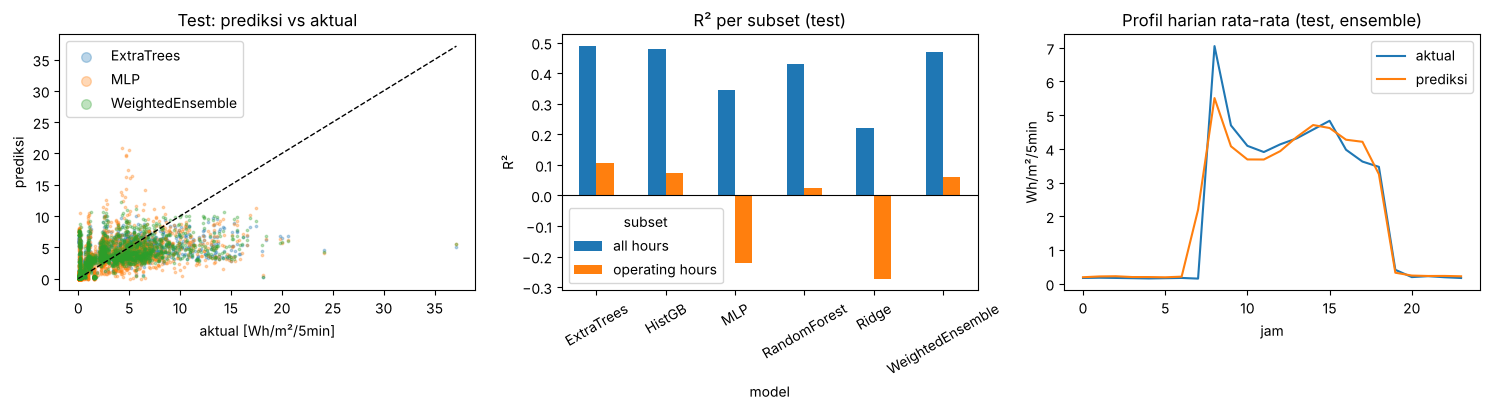

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for name in ("ExtraTrees", "MLP", "WeightedEnsemble"):
    ax[0].scatter(yte, preds[name], s=3, alpha=.3, label=name)
lim = [0, max(yte.max(), 1)]; ax[0].plot(lim, lim, "k--", lw=1)
ax[0].set(xlabel="aktual [Wh/m²/5min]", ylabel="prediksi", title="Test: prediksi vs aktual"); ax[0].legend(markerscale=4)
res.pivot(index="model", columns="subset", values="R2").plot.bar(ax=ax[1])
ax[1].set(title="R² per subset (test)", ylabel="R²"); ax[1].axhline(0, color="k", lw=.8); ax[1].tick_params(axis="x", rotation=30)
te2 = te.assign(pred=preds["WeightedEnsemble"])
te2.groupby(te2.ts.dt.hour)[["hvac_energy_wh_m2", "pred"]].mean().plot(ax=ax[2])
ax[2].set(title="Profil harian rata-rata (test, ensemble)", xlabel="jam", ylabel="Wh/m²/5min"); ax[2].legend(["aktual", "prediksi"])
plt.tight_layout(); plt.savefig(out / "fig_surrogate_performance.png", dpi=130); plt.show()